#### Linear Regression

In linear regression models, the target value is modeled as a linear combination of the features. The model is trained on a dataset with known target values. The model can then be used to predict the target value for new data points.

The linear regression model is defined as:

$$y = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n$$

where $y$ is the target value, $x_1$ to $x_n$ are the feature values, and $w_0$ to $w_n$ are the model parameters. The model parameters are learned during the training process using the least squares method.

The linear regression model can be extended to include non-linear features by using a non-linear transformation of the features. For example, the model can be extended to include quadratic features as follows:

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2$$

The linear regression model can also be extended to include interaction features as follows:

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_1x_2$$

The linear regression model can be extended to include polynomial features and interaction features at the same time as follows:

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_1^2 + w_4x_2^2 + w_5x_1x_2$$

We will now extend the linear regression model to include multiple features.  For the data, we will use a dataset that contains information about effect of various forms of advertising media on product sales. We read the data from a CSV file into a Pandas DataFrame.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Get the data
advert = pd.read_csv('advertising.csv')
print(advert.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


The first step is to look at the data.  A reasonable first step is to plot sales vs. each of the features, individually.

Text(0, 0.5, 'Sales')

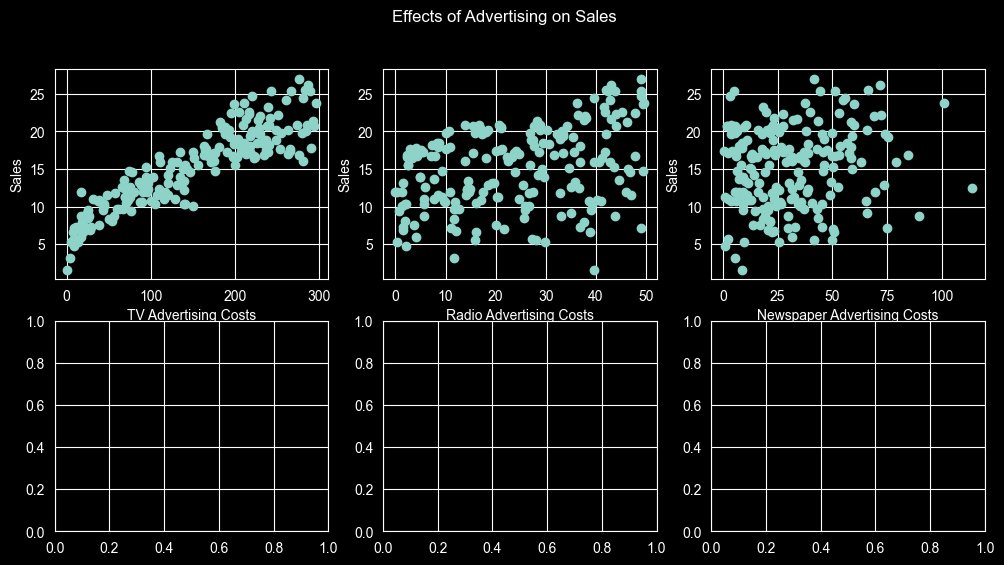

In [3]:
# Look at the data!  Create plots of Sales vs. each variable
fig, ax = plt.subplots(2, 3, figsize=(12,6))
fig.suptitle("Effects of Advertising on Sales")
ax[0][0].plot(advert['TV'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[0][0].set_xlabel('TV Advertising Costs')
ax[0][0].set_ylabel('Sales')

ax[0][1].plot(advert['Radio'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[0][1].set_xlabel('Radio Advertising Costs')
ax[0][1].set_ylabel('Sales')

ax[0][2].plot(advert['Newspaper'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[0][2].set_xlabel('Newspaper Advertising Costs')
ax[0][2].set_ylabel('Sales')

### Initial observations

The strongest visible association is between sales and TV advertising cost. There is a weaker association with Radio and no obvious association with Newspaper.

We will first fit TV alone and then fit each remaining feature to the residuals left by the preceding fit. This is a useful visualization of how one feature may explain variation left by another. However, this particular sequential procedure is generally **not equivalent** to a simultaneous multiple regression: its result can depend on the order of the features.

Afterward, we will fit all three features simultaneously and compare the two approaches.

      TV  Radio  Newspaper  Sales   Sales_TV  Sales_TV_Residual
0  230.1   37.8       69.2   22.1  19.737265           2.362735
1   44.5   39.3       45.1   10.4   9.443004           0.956996
2   17.2   45.9       69.3   12.0   7.928816           4.071184
3  151.5   41.3       58.5   16.5  15.377734           1.122266
4  180.8   10.8       58.4   17.9  17.002852           0.897148
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           7.93e-74
Time:                        14:39:38   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                   

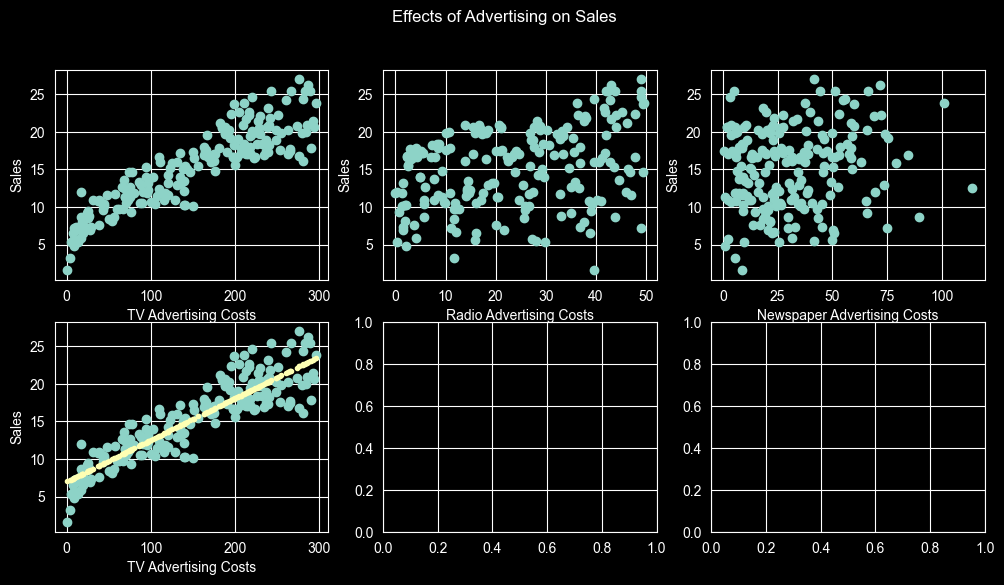

In [4]:
# Fit a linear regression model to a single parameter - Sales vs. TV advertising costs
model = smf.ols('Sales ~ TV', data=advert)
model = model.fit()

# View model summary
# print(model.summary())

# Predict values
sales_pred = model.predict()

# Add this prediction to the DataFrame
advert['Sales_TV'] = sales_pred
# Add the DIFFERENCE between Sales data and prediction to the DataFrame
advert['Sales_TV_Residual'] = advert['Sales'] - sales_pred
print(advert.head())

# Plot regression against actual data
ax[1][0].plot(advert['TV'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[1][0].plot(advert['TV'], sales_pred, '.', linewidth=2, label = "Prediction")   # regression line
ax[1][0].set_xlabel('TV Advertising Costs')
ax[1][0].set_ylabel('Sales')

print(model.summary())

fig

The fitted TV coefficient has a very small p-value. Under the null hypothesis that the TV coefficient is zero, and assuming the regression model is appropriate, data producing a test statistic at least this extreme would be very unlikely.

This is evidence of an association between TV advertising cost and sales; it is not the probability that the null hypothesis is true, nor does it by itself establish causation.

      TV  Radio  Newspaper  Sales   Sales_TV  Sales_TV_Residual  \
0  230.1   37.8       69.2   22.1  19.737265           2.362735   
1   44.5   39.3       45.1   10.4   9.443004           0.956996   
2   17.2   45.9       69.3   12.0   7.928816           4.071184   
3  151.5   41.3       58.5   16.5  15.377734           1.122266   
4  180.8   10.8       58.4   17.9  17.002852           0.897148   

   Radio_Residual_Component  Sales_TV_Radio_Residual  
0                  1.553210                 0.809525  
1                  1.713489                -0.756492  
2                  2.418716                 1.652469  
3                  1.927194                -0.804928  
4                 -1.331811                 2.228959  
                            OLS Regression Results                            
Dep. Variable:      Sales_TV_Residual   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least 

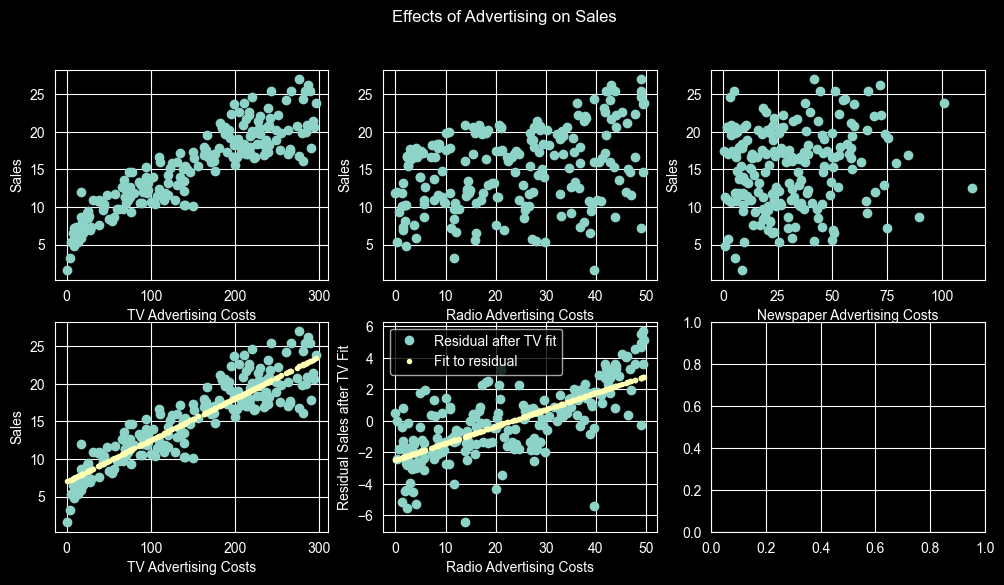

In [5]:
# Fit Radio to the residuals left by the TV-only fit
model2 = smf.ols('Sales_TV_Residual ~ Radio', data=advert).fit()
sales_pred2 = model2.predict()
advert['Radio_Residual_Component'] = sales_pred2
advert['Sales_TV_Radio_Residual'] = advert['Sales_TV_Residual'] - sales_pred2
print(advert.head())

ax[1][1].plot(advert['Radio'], advert['Sales_TV_Residual'], 'o', label='Residual after TV fit')
ax[1][1].plot(advert['Radio'], sales_pred2, '.', label='Fit to residual')
ax[1][1].set_xlabel('Radio Advertising Costs')
ax[1][1].set_ylabel('Residual Sales after TV Fit')
ax[1][1].legend()

print(model2.summary())
fig

The Radio coefficient in this residual fit also has a very small p-value. Conditional on this sequential procedure and its assumptions, the residual variation after the TV-only fit retains a statistically significant association with Radio advertising cost.

This is not a statement that the probability of a chance explanation is 0%. Values printed as `0.000` in a summary have merely been rounded to three decimal places.

      TV  Radio  Newspaper  Sales   Sales_TV  Sales_TV_Residual  \
0  230.1   37.8       69.2   22.1  19.737265           2.362735   
1   44.5   39.3       45.1   10.4   9.443004           0.956996   
2   17.2   45.9       69.3   12.0   7.928816           4.071184   
3  151.5   41.3       58.5   16.5  15.377734           1.122266   
4  180.8   10.8       58.4   17.9  17.002852           0.897148   

   Radio_Residual_Component  Sales_TV_Radio_Residual  \
0                  1.553210                 0.809525   
1                  1.713489                -0.756492   
2                  2.418716                 1.652469   
3                  1.927194                -0.804928   
4                 -1.331811                 2.228959   

   Newspaper_Residual_Component  Sequential_Final_Residual  
0                      0.005564                   0.803961  
1                      0.002094                  -0.758587  
2                      0.005579                   1.646890  
3               

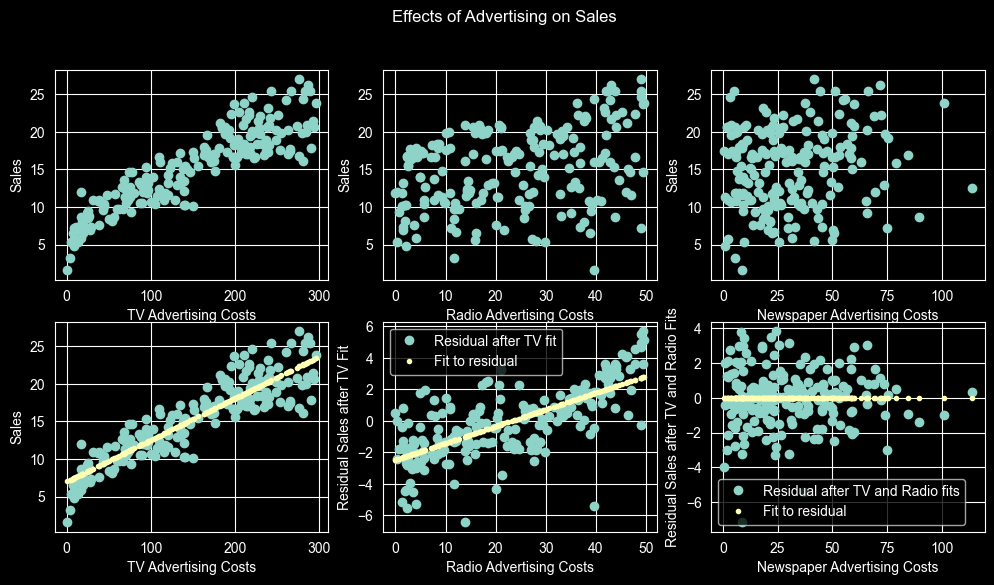

In [6]:
# Fit Newspaper to the residuals left by the TV-then-Radio sequence
model3 = smf.ols('Sales_TV_Radio_Residual ~ Newspaper', data=advert).fit()
sales_pred3 = model3.predict()
advert['Newspaper_Residual_Component'] = sales_pred3
advert['Sequential_Final_Residual'] = advert['Sales_TV_Radio_Residual'] - sales_pred3
print(advert.head())

ax[1][2].plot(advert['Newspaper'], advert['Sales_TV_Radio_Residual'], 'o',
              label='Residual after TV and Radio fits')
ax[1][2].plot(advert['Newspaper'], sales_pred3, '.', label='Fit to residual')
ax[1][2].set_xlabel('Newspaper Advertising Costs')
ax[1][2].set_ylabel('Residual Sales after TV and Radio Fits')
ax[1][2].legend()

fig

In [ ]:
# Now perform the statistically standard simultaneous multiple regression
model_multiple = smf.ols('Sales ~ TV + Radio + Newspaper', data=advert).fit()
advert['Sales_Multiple'] = model_multiple.predict()
advert['Multiple_Residual'] = advert['Sales'] - advert['Sales_Multiple']

rss_sequential = np.sum(advert['Sequential_Final_Residual']**2)
rss_multiple = np.sum(advert['Multiple_Residual']**2)

print(model_multiple.summary())
print()
print(f"Sequential residual-fit RSS: {rss_sequential:.3f}")
print(f"Simultaneous multiple-regression RSS: {rss_multiple:.3f}")

fig_compare, compare_ax = plt.subplots(1, 2, figsize=(12, 5))
compare_ax[0].plot(advert['Sales'], advert['Sales_Multiple'], 'o')
limits = [advert['Sales'].min(), advert['Sales'].max()]
compare_ax[0].plot(limits, limits, '--', label='Perfect prediction')
compare_ax[0].set_xlabel('Measured Sales')
compare_ax[0].set_ylabel('Predicted Sales')
compare_ax[0].legend()

compare_ax[1].plot(advert['Sales_Multiple'], advert['Multiple_Residual'], 'o')
compare_ax[1].axhline(0, linestyle='--')
compare_ax[1].set_xlabel('Predicted Sales')
compare_ax[1].set_ylabel('Residual')
fig_compare.suptitle('Simultaneous Multiple Regression Diagnostics')
plt.show()

### Final observations

The sequential residual plots help visualize how additional features can account for unexplained variation. However, because the predictors are correlated, fitting raw predictors to successive residuals is order-dependent and is not generally identical to fitting all predictors simultaneously. The simultaneous model is the appropriate model for estimating the partial contribution of each feature while holding the others fixed.

In the simultaneous fit, TV and Radio have small p-values, whereas Newspaper has a large p-value. A large Newspaper p-value means that the data do not provide evidence against a zero Newspaper coefficient after accounting for TV and Radio. It does **not** mean that there is an 86% probability that its apparent effect is random, and it does not prove that the true coefficient is exactly zero.

Likewise, the regression establishes associations in this dataset, not necessarily causal effects of changing advertising spending.